# ML Models for Time Seriese

This notebook will test out different time series models and look at there strength and weekneses.

## Libraries

**Important:**

Install numpy 2.0 instead of the newest version, because Darts still works on the old versions.

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Parameters

In [266]:
path = "../data/procesed/"

random_seed = 42

## Loading Timeseries ABT

Loading the timeseries ABT from procesed folder.

In [267]:
timeseries = pd.read_csv(path+"timeseries_ABT.csv")

timeseries.head()

,Unnamed: 0,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake
0,2013-01-02,582.0,2013,1,2,2,0,93.14,0,0
1,2013-01-03,310.0,2013,1,3,3,0,92.97,0,0
2,2013-01-04,338.0,2013,1,4,4,0,93.12,0,0
3,2013-01-05,654.0,2013,1,5,5,1,93.12,0,0
4,2013-01-06,979.0,2013,1,6,6,0,93.12,0,0


In [268]:
timeseries.columns = ['date', 'unit_sales', 'year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico', 'is_payday', 'is_earthquake']
timeseries['date'] = pd.to_datetime(timeseries['date'])
timeseries.set_index('date', inplace=True)

# Feature Engineering

- Lags
- Rolling Average (Rolling Window)
- Expanding Window (comulative average)

> **Always use exluding Windows: To Avoid Information Lekage**

### Features

In [269]:
featured_timeseries = timeseries.copy()

featured_timeseries['is_weekend'] = featured_timeseries['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# lag 1
featured_timeseries['lag_1'] = featured_timeseries['unit_sales'].shift(1)
# lag 2
featured_timeseries['lag_2'] = featured_timeseries['unit_sales'].shift(2)
# lag 4
featured_timeseries['lag_4'] = featured_timeseries['unit_sales'].shift(4)
# lag 5
featured_timeseries['lag_5'] = featured_timeseries['unit_sales'].shift(5)
# lag 6
featured_timeseries['lag_6'] = featured_timeseries['unit_sales'].shift(6)
# lag 7
featured_timeseries['lag_7'] = featured_timeseries['unit_sales'].shift(7)
# lag 9
featured_timeseries['lag_9'] = featured_timeseries['unit_sales'].shift(9)
# lag 12
featured_timeseries['lag_12'] = featured_timeseries['unit_sales'].shift(12)
# lag 13
featured_timeseries['lag_13'] = featured_timeseries['unit_sales'].shift(13)
# lag 14
featured_timeseries['lag_14'] = featured_timeseries['unit_sales'].shift(14)
# lag 16
featured_timeseries['lag_16'] = featured_timeseries['unit_sales'].shift(16)
# lag 19
featured_timeseries['lag_19'] = featured_timeseries['unit_sales'].shift(19)
# lag 21
featured_timeseries['lag_21'] = featured_timeseries['unit_sales'].shift(21)

# rolling 2
featured_timeseries['rolling_mean_2'] = featured_timeseries['unit_sales'].rolling(window=2, closed='left', ).mean()
# rolling 3
featured_timeseries['rolling_mean_3'] = featured_timeseries['unit_sales'].rolling(window=3, closed='left').mean()
# rolling 4
featured_timeseries['rolling_mean_4'] = featured_timeseries['unit_sales'].rolling(window=4, closed='left').mean()
# rolling 5
featured_timeseries['rolling_mean_5'] = featured_timeseries['unit_sales'].rolling(window=5, closed='left').mean()
# rolling 6
featured_timeseries['rolling_mean_6'] = featured_timeseries['unit_sales'].rolling(window=6, closed='left').mean()
# rolling 7
featured_timeseries['rolling_mean_7'] = featured_timeseries['unit_sales'].rolling(window=7, closed='left').mean()
# rolling 9
featured_timeseries['rolling_mean_9'] = featured_timeseries['unit_sales'].rolling(window=9, closed='left').mean()
# rolling 12
featured_timeseries['rolling_mean_12'] = featured_timeseries['unit_sales'].rolling(window=12, closed='left').mean()
# rolling 14
featured_timeseries['rolling_mean_14'] = featured_timeseries['unit_sales'].rolling(window=14, closed='left').mean()
# rolling 16
featured_timeseries['rolling_mean_16'] = featured_timeseries['unit_sales'].rolling(window=16, closed='left').mean()
# rolling 19
featured_timeseries['rolling_mean_19'] = featured_timeseries['unit_sales'].rolling(window=19, closed='left').mean()
# rolling 21
featured_timeseries['rolling_mean_21'] = featured_timeseries['unit_sales'].rolling(window=21, closed='left').mean()
# rolling 28
featured_timeseries['rolling_mean_28'] = featured_timeseries['unit_sales'].rolling(window=28, closed='left').mean()
# rolling 35
featured_timeseries['rolling_mean_35'] = featured_timeseries['unit_sales'].rolling(window=35, closed='left').mean()


# rolling 7
featured_timeseries['rolling_std_7'] = featured_timeseries['unit_sales'].rolling(window=7, closed='left').std()
# rolling 14
featured_timeseries['rolling_std_14'] = featured_timeseries['unit_sales'].rolling(window=14, closed='left').std()
# rolling 21
featured_timeseries['rolling_std_21'] = featured_timeseries['unit_sales'].rolling(window=21, closed='left').std()
# rolling 28
featured_timeseries['rolling_std_28'] = featured_timeseries['unit_sales'].rolling(window=28, closed='left').std()
# rolling 35
featured_timeseries['rolling_std_35'] = featured_timeseries['unit_sales'].rolling(window=35, closed='left').std()


featured_timeseries.head(10)

,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake,is_weekend,...,rolling_mean_16,rolling_mean_19,rolling_mean_21,rolling_mean_28,rolling_mean_35,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_28,rolling_std_35
date,,,,,,,,,,,,,,,,,,,,,
2013-01-02,582.0,2013,1,2,2,0,93.14,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,310.0,2013,1,3,3,0,92.97,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,338.0,2013,1,4,4,0,93.12,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-05,654.0,2013,1,5,5,1,93.12,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-06,979.0,2013,1,6,6,0,93.12,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-07,541.0,2013,1,7,0,0,93.20,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-08,434.0,2013,1,8,1,0,93.21,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-09,593.0,2013,1,9,2,0,93.08,0,0,0,...,NaN,NaN,NaN,NaN,NaN,228.013680,NaN,NaN,NaN,NaN
2013-01-10,700.0,2013,1,10,3,0,93.81,0,0,0,...,NaN,NaN,NaN,NaN,NaN,228.322454,NaN,NaN,NaN,NaN


In [270]:
# Drop nan
featured_timeseries = featured_timeseries.dropna()
featured_timeseries.head(5)

,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake,is_weekend,...,rolling_mean_16,rolling_mean_19,rolling_mean_21,rolling_mean_28,rolling_mean_35,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_28,rolling_std_35
date,,,,,,,,,,,,,,,,,,,,,
2013-02-06,461.0,2013,2,6,2,0,96.44,0,0,0,...,491.0000,509.105263,473.428571,517.892857,523.971429,230.581769,187.398573,263.740132,242.033414,236.318515
2013-02-07,397.0,2013,2,7,3,0,95.84,0,0,0,...,472.3125,530.210526,482.761905,513.178571,520.514286,230.989486,186.635641,259.428199,241.801733,236.329701
2013-02-08,226.0,2013,2,8,4,0,95.71,0,0,0,...,468.3125,516.000000,501.476190,502.357143,523.000000,217.081179,183.138331,236.309885,239.903872,234.500847
2013-02-09,377.0,2013,2,9,5,0,95.71,0,0,1,...,456.6250,470.526316,509.380952,484.500000,519.800000,240.570651,194.371642,223.217490,241.245457,237.840010
2013-02-10,356.0,2013,2,10,6,0,95.71,0,0,1,...,459.8125,450.368421,495.571429,475.428571,511.885714,205.104735,184.276742,221.945618,240.306352,237.851755


In [271]:
# get index out.
featured_timeseries = featured_timeseries.reset_index(drop=False)
featured_timeseries.head(5)

,date,unit_sales,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake,...,rolling_mean_16,rolling_mean_19,rolling_mean_21,rolling_mean_28,rolling_mean_35,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_28,rolling_std_35
0,2013-02-06,461.0,2013,2,6,2,0,96.44,0,0,...,491.0000,509.105263,473.428571,517.892857,523.971429,230.581769,187.398573,263.740132,242.033414,236.318515
1,2013-02-07,397.0,2013,2,7,3,0,95.84,0,0,...,472.3125,530.210526,482.761905,513.178571,520.514286,230.989486,186.635641,259.428199,241.801733,236.329701
2,2013-02-08,226.0,2013,2,8,4,0,95.71,0,0,...,468.3125,516.000000,501.476190,502.357143,523.000000,217.081179,183.138331,236.309885,239.903872,234.500847
3,2013-02-09,377.0,2013,2,9,5,0,95.71,0,0,...,456.6250,470.526316,509.380952,484.500000,519.800000,240.570651,194.371642,223.217490,241.245457,237.840010
4,2013-02-10,356.0,2013,2,10,6,0,95.71,0,0,...,459.8125,450.368421,495.571429,475.428571,511.885714,205.104735,184.276742,221.945618,240.306352,237.851755


## Machine Learning Models

Common ML models for time-series

**Tree-based ensembles** – Gradient Boosting, XGBoost, LightGBM
- Pros: fast, interpretable feature importance, handles missing values.
- Cons: need manual lag/rolling features; can’t extrapolate far beyond training range.

**Recurrent Neural Networks** (RNN, LSTM, GRU)
- Pros: learn long-term dependencies; work well with multiple covariates.
- Cons: slower to train, require more data and tuning.

**Temporal Convolutional Networks** (TCN) & 1-D CNNs
- Faster than RNNs, good for long sequences, easier to parallelise.

**Transformers / Attention models**
- State-of-the-art for long horizons and complex patterns; require GPU and large data.

**Hybrid or “Statistical + ML”**
- Combine trend/seasonality removal (STL) with ML on residuals; provides best of both worlds.

### Test, Learn Split

In [272]:
# Define target variable (unit_sales) and features
X = featured_timeseries.drop('unit_sales', axis=1)
y = featured_timeseries[['unit_sales']]

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [273]:
# extract dates for later plotting
X_train_dates = X_train['date']
X_test_dates = X_test['date']

# delete dates from df
X_train = X_train.drop('date', axis=1)
X_test = X_test.drop('date', axis=1)

In [274]:
X_train.head(5)

,year,month,day,day_of_week,is_holiday,dcoilwtico,is_payday,is_earthquake,is_weekend,lag_1,...,rolling_mean_16,rolling_mean_19,rolling_mean_21,rolling_mean_28,rolling_mean_35,rolling_std_7,rolling_std_14,rolling_std_21,rolling_std_28,rolling_std_35
0,2013,2,6,2,0,96.44,0,0,0,272.0,...,491.0000,509.105263,473.428571,517.892857,523.971429,230.581769,187.398573,263.740132,242.033414,236.318515
1,2013,2,7,3,0,95.84,0,0,0,461.0,...,472.3125,530.210526,482.761905,513.178571,520.514286,230.989486,186.635641,259.428199,241.801733,236.329701
2,2013,2,8,4,0,95.71,0,0,0,397.0,...,468.3125,516.000000,501.476190,502.357143,523.000000,217.081179,183.138331,236.309885,239.903872,234.500847
3,2013,2,9,5,0,95.71,0,0,1,226.0,...,456.6250,470.526316,509.380952,484.500000,519.800000,240.570651,194.371642,223.217490,241.245457,237.840010
4,2013,2,10,6,0,95.71,0,0,1,377.0,...,459.8125,450.368421,495.571429,475.428571,511.885714,205.104735,184.276742,221.945618,240.306352,237.851755


In [275]:
X_train.columns

Index(['year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico',
       'is_payday', 'is_earthquake', 'is_weekend', 'lag_1', 'lag_2', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'lag_9', 'lag_12', 'lag_13', 'lag_14',
       'lag_16', 'lag_19', 'lag_21', 'rolling_mean_2', 'rolling_mean_3',
       'rolling_mean_4', 'rolling_mean_5', 'rolling_mean_6', 'rolling_mean_7',
       'rolling_mean_9', 'rolling_mean_12', 'rolling_mean_14',
       'rolling_mean_16', 'rolling_mean_19', 'rolling_mean_21',
       'rolling_mean_28', 'rolling_mean_35', 'rolling_std_7', 'rolling_std_14',
       'rolling_std_21', 'rolling_std_28', 'rolling_std_35'],
      dtype='object')

In [276]:
y_train.head(5)

,unit_sales
0,461.0
1,397.0
2,226.0
3,377.0
4,356.0


### Function for forcasting

to forcast values write function with input model, test_df, numbers to predict, columns from train df

1. convert test and columns from train df to timeseries
2. copy unit sales from test as history
3. get last date from history
4. create new empty list = forecast
4. use history to calcuate unit sales based and date based columns
5. create row dataframe from these columns
6. inner join the columns from train df based on date
7. use this row df to predict y_hat via model
8. write y_hat also to history

In [277]:
def forecasting_pipeline(model, y_train, x_dates, num_days, test, test_dates, test_columns):
    """
    This Function builds the forecast for timeseries data for machine learining models by avoiding data leakage.

    The inputs are:
    - model
    - y_train
    - x_dates
    - number of days to forecast
    - train df
    - train columns for Xeogenos variables as list of strings
    """
    import pandas as pd
    import numpy as np

    # create test timeseries
    history = y_train.copy().set_index(x_dates)
    # set dates for test set
    xogen = test.copy().set_index(test_dates)
    # last date in the training set
    last_date = history.index[-1]
    # future dates
    future = []
    for i in range(num_days):
        # create future date
        next_date = last_date + pd.Timedelta(days=1)

        # --- Create Lags ---
        # Using .iloc[n] for specific positions
        lag_1 = history['unit_sales'].iloc[-1]
        lag_2 = history['unit_sales'].iloc[-2]
        lag_4 = history['unit_sales'].iloc[-4]
        lag_5 = history['unit_sales'].iloc[-5]
        lag_6 = history['unit_sales'].iloc[-6]
        lag_7 = history['unit_sales'].iloc[-7]
        lag_9 = history['unit_sales'].iloc[-9]
        lag_12 = history['unit_sales'].iloc[-12]
        lag_13 = history['unit_sales'].iloc[-13]
        lag_14 = history['unit_sales'].iloc[-14]
        lag_16 = history['unit_sales'].iloc[-16]
        lag_19 = history['unit_sales'].iloc[-19]
        lag_21 = history['unit_sales'].iloc[-21]

        # --- Create Rolling Means ---
        # Using .iloc[start:end] for position-based slicing
        rolling_mean_2 = history['unit_sales'].iloc[-2:].mean()
        rolling_mean_3 = history['unit_sales'].iloc[-3:].mean()
        rolling_mean_4 = history['unit_sales'].iloc[-4:].mean()
        rolling_mean_5 = history['unit_sales'].iloc[-5:].mean()
        rolling_mean_6 = history['unit_sales'].iloc[-6:].mean()
        rolling_mean_7 = history['unit_sales'].iloc[-7:].mean()
        rolling_mean_9 = history['unit_sales'].iloc[-9:].mean()
        rolling_mean_12 = history['unit_sales'].iloc[-12:].mean()
        rolling_mean_14 = history['unit_sales'].iloc[-14:].mean()
        rolling_mean_16 = history['unit_sales'].iloc[-16:].mean()
        rolling_mean_19 = history['unit_sales'].iloc[-19:].mean()
        rolling_mean_21 = history['unit_sales'].iloc[-21:].mean()
        rolling_mean_28 = history['unit_sales'].iloc[-28:].mean()
        rolling_mean_35 = history['unit_sales'].iloc[-35:].mean()

        # --- Create Rolling Std ---
        rolling_std_7 = history['unit_sales'].iloc[-7:].std()
        rolling_std_14 = history['unit_sales'].iloc[-14:].std()
        rolling_std_21 = history['unit_sales'].iloc[-21:].std()
        rolling_std_28 = history['unit_sales'].iloc[-28:].std()
        rolling_std_35 = history['unit_sales'].iloc[-35:].std()

        # create row DataFrame
        row = pd.DataFrame(data=
                           {
                                'lag_1' : [lag_1],
                                'lag_2': [lag_2],
                                'lag_4' : [lag_4],
                                'lag_5' : [lag_5],
                                'lag_6' : [lag_6],
                                'lag_7' : [lag_7],
                                'lag_9' : [lag_9],
                                'lag_12' : [lag_12],
                                'lag_13' : [lag_13],
                                'lag_14' : [lag_14],
                                'lag_16' : [lag_16],
                                'lag_19' : [lag_19],
                                'lag_21' : [lag_21],
                                'rolling_mean_2' : [rolling_mean_2],
                                'rolling_mean_3' : [rolling_mean_3],
                                'rolling_mean_4' : [rolling_mean_4],
                                'rolling_mean_5' : [rolling_mean_5],
                                'rolling_mean_6' : [rolling_mean_6],
                                'rolling_mean_7' : [rolling_mean_7],
                                'rolling_mean_9' : [rolling_mean_9],
                                'rolling_mean_12' : [rolling_mean_12],
                                'rolling_mean_14' : [rolling_mean_14],
                                'rolling_mean_16' : [rolling_mean_16],
                                'rolling_mean_19' : [rolling_mean_19],
                                'rolling_mean_21' : [rolling_mean_21],
                                'rolling_mean_28' : [rolling_mean_28],
                                'rolling_mean_35' : [rolling_mean_35],
                                'rolling_std_7' : [rolling_std_7],
                                'rolling_std_14' : [rolling_std_14],
                                'rolling_std_21' : [rolling_std_21],
                                'rolling_std_28' : [rolling_std_28],
                                'rolling_std_35' : [rolling_std_35]
                           },
                           index=[next_date])
        rows = row.merge(xogen[test_columns], how='left', left_index=True, right_index=True)
        # sort rows by columns to fir model input
        cols = xogen.columns
        rows = rows[cols]

        if rows.isnull().any().any():
            print(f"Warning: Missing values in features for date {next_date}. Filling with zeros.")
            print(rows.isnull().sum())
            rows = rows.fillna(0)

        # predict next value
        y_hat = model.predict(rows)[0]
        # append prediction to forecast
        future.append(y_hat)
        # update history with prediction
        history = pd.concat([history,pd.DataFrame(data={'unit_sales': y_hat}, index=[next_date])])
        # update last date        last_date = next_date
        last_date = next_date
    return future

        

### XG-Boost

In [278]:
print(f"Your NumPy version: {np.__version__}")

Your NumPy version: 1.26.4


In [279]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
                    objective='reg:squarederror', 
                    n_estimators=100, 
                    max_depth=5, 
                    learning_rate=0.1,
                    #categorical=True,
                    #tree_method='hist',  # Essential for larger datasets
                    #device='cpu',
                    n_jobs=-1,          # Uses all CPU cores (or set to 1 if you suspect a crash)
                    verbosity=2,         # Tells you exactly what it's doing while it works
                    random_state=random_seed
                    )

In [280]:
xgboost_model.fit(
    X_train, y_train
)

[14:58:42] INFO: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (335, 41, 13735).


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [281]:
# Make predictions on the test set
y_pred = forecasting_pipeline(xgboost_model, y_train, X_train_dates, len(X_test), X_test, X_test_dates, ['year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico',
       'is_payday', 'is_earthquake', 'is_weekend'])

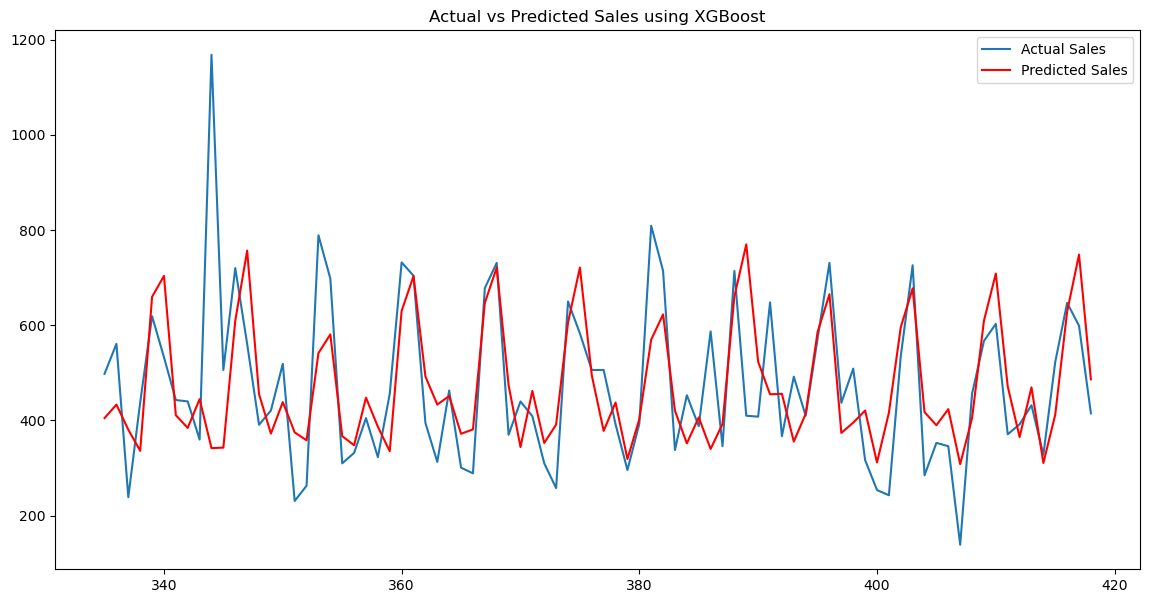

In [282]:
# Plot the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using XGBoost')
plt.legend()
plt.show()

In [283]:
# y_test and y_pred are Pandas Series aligned by date
mae  = mean_absolute_error(y_test, y_pred)

print(f"MAE : {mae:.3f} units")

mape_score = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAPE : {mape_score * 100:.2f}%")

MAE : 97.996 units
MAPE : 22.37%


### Iterative XG-Boost Approach

In [284]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
                    objective='reg:squarederror', 
                    n_estimators=150, 
                    max_depth=15,
                    early_stopping_rounds=15, 
                    learning_rate=0.1,
                    #categorical=True,
                    #tree_method='hist',  # Essential for larger datasets
                    #device='cpu',
                    n_jobs=-1,          # Uses all CPU cores (or set to 1 if you suspect a crash)
                    verbosity=2,         # Tells you exactly what it's doing while it works
                    random_state=random_seed,
                    eval_metric=["mape", "rmse"], # You can track multiple metrics
                    )

# led the fit directly evaluate the moddel to fine tune the number of estimators.
xgboost_model.fit(X_train, y_train,
                  eval_set=[(X_train, y_train),(X_test, y_test)],
                  verbose=True # this will make the fit print out every fitted tree
)

[14:58:42] INFO: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (335, 41, 13735).
[14:58:42] INFO: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125106903/work/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (84, 41, 3444).
[0]	validation_0-mape:0.26592	validation_0-rmse:148.66429	validation_1-mape:0.31422	validation_1-rmse:165.21811
[1]	validation_0-mape:0.24342	validation_0-rmse:136.47534	validation_1-mape:0.30477	validation_1-rmse:161.63444
[2]	validation_0-mape:0.22285	validation_0-rmse:125.39011	validation_1-mape:0.29207	validation_1-rmse:158.96390
[3]	validation_0-mape:0.20398	validation_0-rmse:115.29813	validation_1-mape:0.28211	validation_1-rmse:157.05105
[4]	validation_0-mape:0.18691	validation_0-rmse:106.14192	validation_1-mape:0.27416	validation_1-rmse:155.81576
[5]	validation_0-mape:0.17145	validation_0-rmse:97.81556	validation_1-mape:0

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",15
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

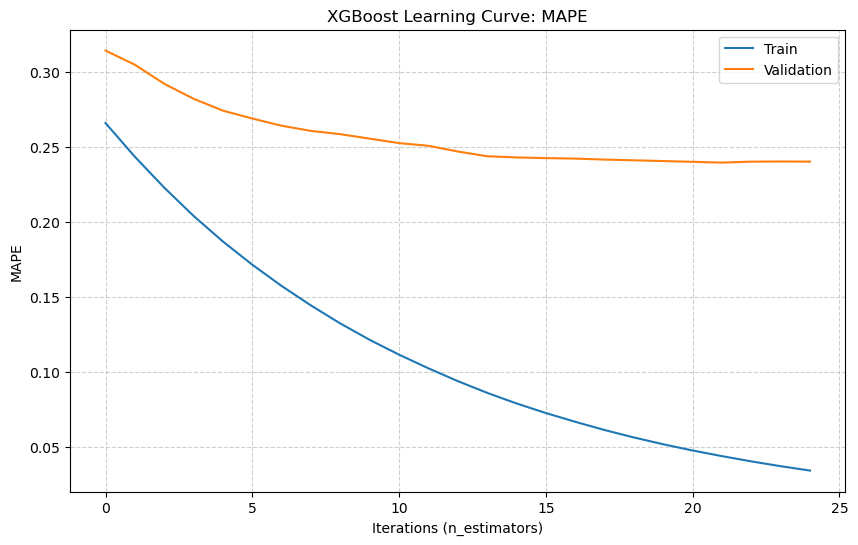

In [285]:
results = xgboost_model.evals_result()

def plot_learning_curves(results, metric='mae'):
    epochs = len(results['validation_0'][metric])
    x_axis = range(0, epochs)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_axis, results['validation_0'][metric], label='Train')
    plt.plot(x_axis, results['validation_1'][metric], label='Validation')
    
    plt.legend()
    plt.ylabel(metric.upper())
    plt.xlabel('Iterations (n_estimators)')
    plt.title(f'XGBoost Learning Curve: {metric.upper()}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Usage:
plot_learning_curves(results, metric='mape')

MAE : 108.107 units
MAPE : 25.98%


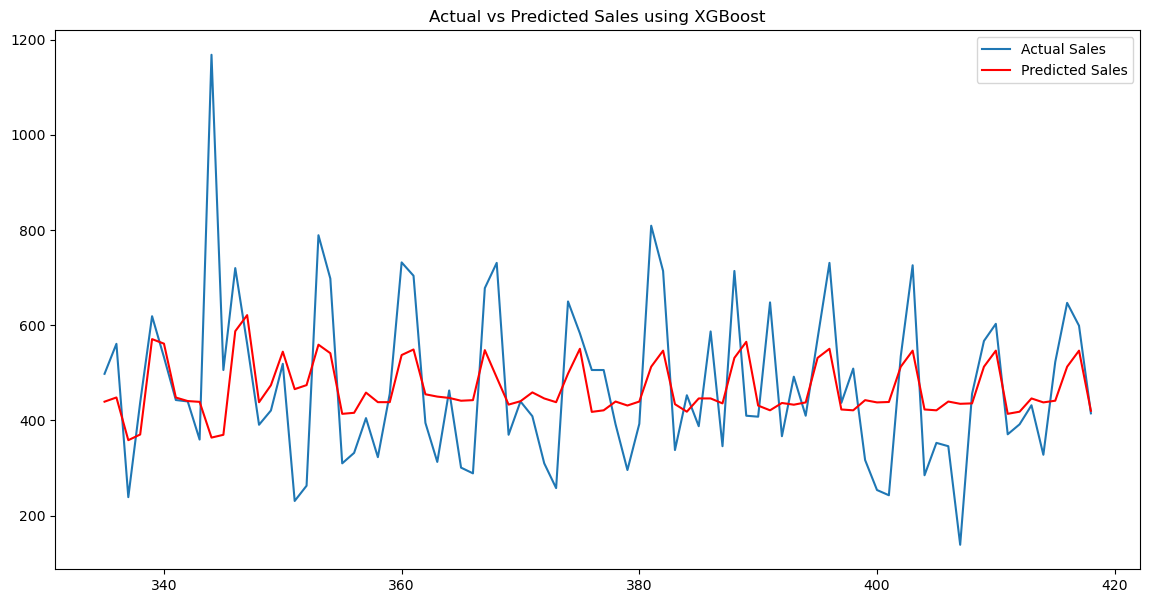

In [286]:

# Make predictions on the test set
y_pred = forecasting_pipeline(xgboost_model, y_train, X_train_dates, len(X_test), X_test, X_test_dates, ['year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico',
       'is_payday', 'is_earthquake', 'is_weekend'])
# y_test and y_pred are Pandas Series aligned by date
mae  = mean_absolute_error(y_test, y_pred)

print(f"MAE : {mae:.3f} units")

mape_score = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAPE : {mape_score * 100:.2f}%")
# Plot the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using XGBoost')
plt.legend()
plt.show()

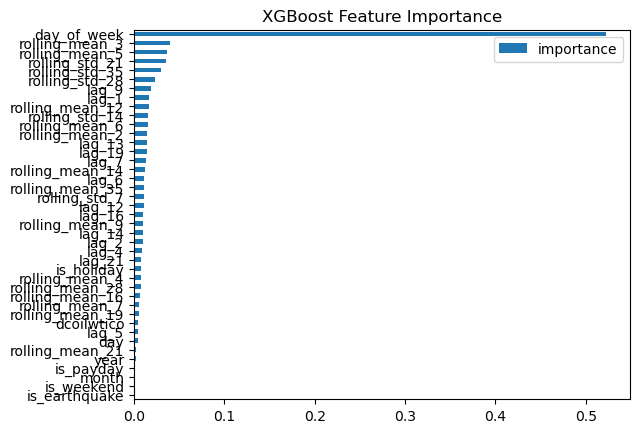

,importance
day_of_week,0.522907
rolling_mean_3,0.040009
rolling_mean_5,0.036350
rolling_std_21,0.035628
rolling_std_35,0.029490
rolling_std_28,0.023467
lag_9,0.018931
lag_1,0.016887
rolling_mean_12,0.016485
rolling_std_14,0.015938


In [287]:
fi = pd.DataFrame(data=xgboost_model.feature_importances_,
                  index=xgboost_model.feature_names_in_,
                  columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='XGBoost Feature Importance')
plt.show()
fi.sort_values('importance',ascending=False).head(10)

### Linear Regression

In [288]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
# Make predictions on the test set
y_pred_linreg = forecasting_pipeline(linreg, y_train, X_train_dates, len(X_test), X_test, X_test_dates, ['year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico',
       'is_payday', 'is_earthquake', 'is_weekend'])


MAE : 167.218 units
MAPE : 44.19%


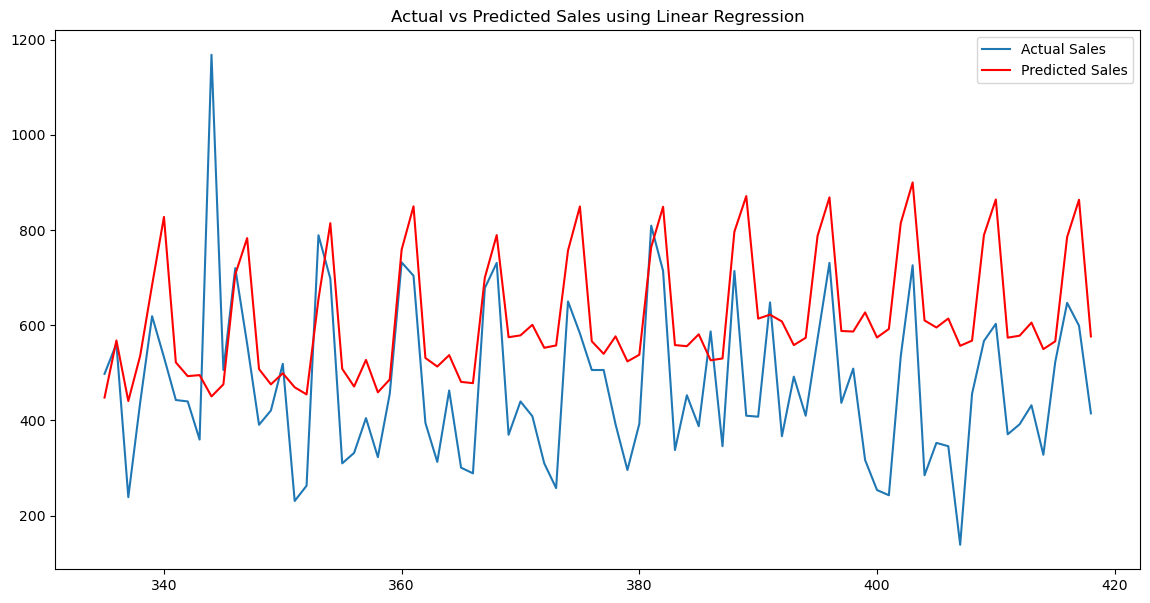

In [289]:
# y_test and y_pred are Pandas Series aligned by date
mae  = mean_absolute_error(y_test, y_pred_linreg)

print(f"MAE : {mae:.3f} units")

mape_score = mean_absolute_percentage_error(y_test, y_pred_linreg)

print(f"MAPE : {mape_score * 100:.2f}%")
# Plot the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred_linreg, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using Linear Regression')
plt.legend()
plt.show()

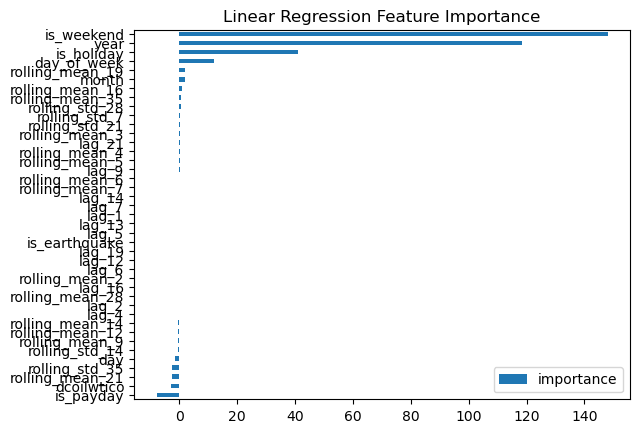

,importance
is_weekend,147.986805
year,118.553789
is_holiday,41.057497
day_of_week,11.875011
rolling_mean_19,1.918683
month,1.904015
rolling_mean_16,0.999296
rolling_mean_35,0.753278
rolling_std_28,0.626246
rolling_std_7,0.405454


In [290]:
fi = pd.DataFrame(data=linreg.coef_.flatten(),
                  index=X.drop('date', axis=1).columns,
                  columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Linear Regression Feature Importance')
plt.show()
fi.sort_values('importance',ascending=False).head(10)

### Random Forest

In [291]:
ranfor = RandomForestRegressor()
ranfor.fit(X_train, y_train)
y_pred_ranfor = forecasting_pipeline(ranfor, y_train, X_train_dates, len(X_test), X_test, X_test_dates, ['year', 'month', 'day', 'day_of_week', 'is_holiday', 'dcoilwtico',
       'is_payday', 'is_earthquake', 'is_weekend'])

/opt/homebrew/Caskroom/miniforge/base/envs/ml_timeseries_env/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MAE : 87.217 units
MAPE : 20.35%


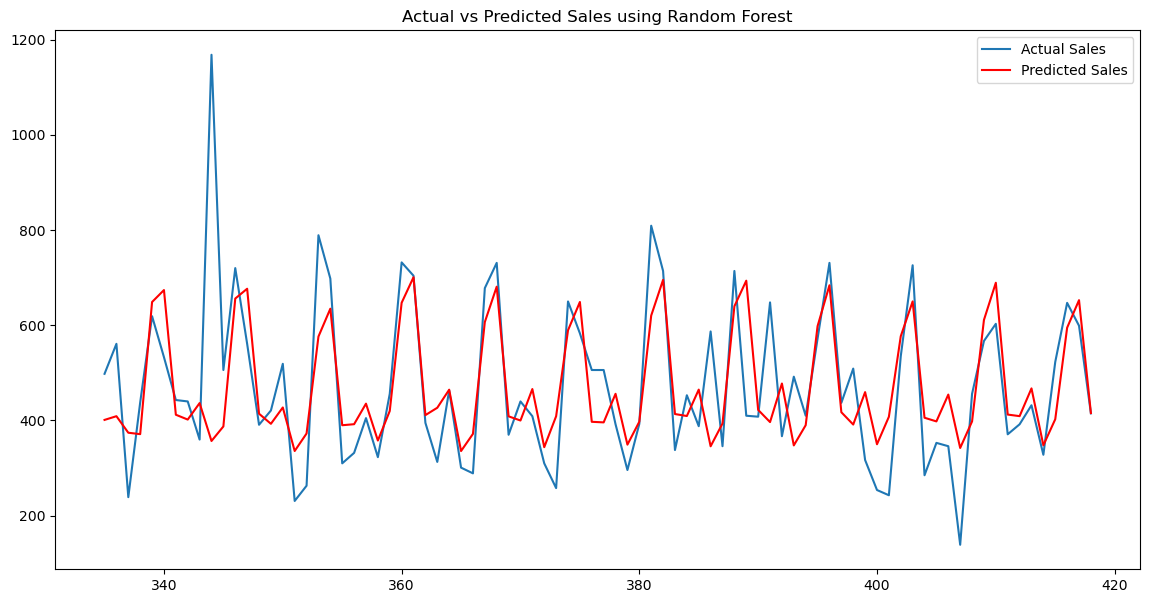

In [292]:
# y_test and y_pred are Pandas Series aligned by date
mae  = mean_absolute_error(y_test, y_pred_ranfor)

print(f"MAE : {mae:.3f} units")

mape_score = mean_absolute_percentage_error(y_test, y_pred_ranfor)

print(f"MAPE : {mape_score * 100:.2f}%")
# Plot the actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Sales')
plt.plot(y_test.index, y_pred_ranfor, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using Random Forest')
plt.legend()
plt.show()

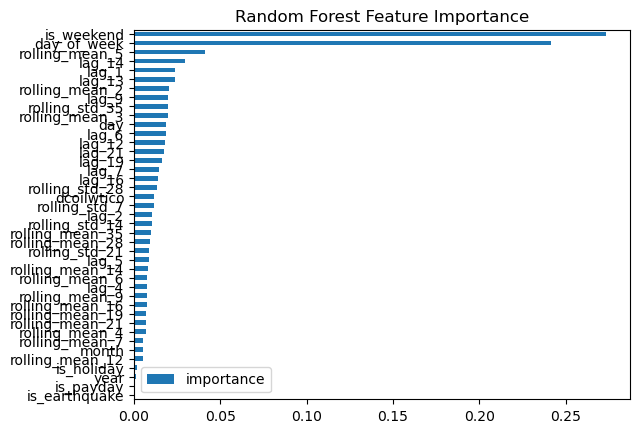

,importance
is_weekend,0.273747
day_of_week,0.241776
rolling_mean_5,0.041302
lag_14,0.029213
lag_1,0.023617
lag_13,0.023582
rolling_mean_2,0.020054
lag_9,0.019870
rolling_std_35,0.019785
rolling_mean_3,0.019579


In [293]:
fi = pd.DataFrame(data=ranfor.feature_importances_.flatten(),
                  index=X.drop('date', axis=1).columns,
                  columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Random Forest Feature Importance')
plt.show()
fi.sort_values('importance',ascending=False).head(10)

### LSTM